# Embryo Development Stage Classification
## CNN (EfficientNet-B0) + LSTM

**Pipeline:**
1. Load frame-level annotations for 16 embryo development phases
2. Embryo-level train / val / test split (rare-class aware)
3. Sliding-window sequences (length = 5) per embryo — no frame sampling
4. EfficientNet-B0 extracts spatial features per frame → LSTM models temporal context
5. Train with class-balanced Focal Cross-Entropy + Cosine LR schedule
6. Evaluate: accuracy, weighted-F1, confusion matrix, per-class F1

In [1]:
import kagglehub

dataset_path = kagglehub.dataset_download('abhishekbuddiga06/embryo-dataset')
print(f'Dataset downloaded to: {dataset_path}')

Dataset downloaded to: /kaggle/input/datasets/abhishekbuddiga06/embryo-dataset


In [2]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

Device  : cuda
PyTorch : 2.10.0+cu128


In [3]:


DATA_DIR = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset/'
ANN_DIR  = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations'

VIDEO_SAMPLE_FRAC = 0.5
VIDEO_SAMPLE_SEED = 42

SEQ_LEN    = 5    # 5 consecutive frames per sequence
SEQ_STRIDE = 3    # stride of 1 → every possible window, no frames skipped

IMG_SIZE  = 96
CROP_SIZE = 96

BATCH_SIZE   = 16
NUM_EPOCHS   = 5
LR           = 2e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS  = 2
PATIENCE     = 3

LSTM_HIDDEN  = 256
LSTM_LAYERS  = 2
LSTM_DROPOUT = 0.3
NUM_CLASSES  = 16

GAMMA        = 2.0
LABEL_SMOOTH = 0.1

PHASES = [
    'tPB2', 'tPNa', 'tPNf', 't2',  't3',  't4',
    't5',   't6',   't7',   't8',  't9+', 'tM',
    'tSB',  'tB',   'tEB',  'tHB'
]
label_map = {phase: idx for idx, phase in enumerate(PHASES)}

print(f'Video sampling : {int(VIDEO_SAMPLE_FRAC*100)}% of videos')
print(f'Sequence length: {SEQ_LEN} frames  |  Stride: {SEQ_STRIDE} (no frame skipping)')
print(f'Epochs         : {NUM_EPOCHS}')
print(f'Model          : EfficientNet-B0 + LSTM')
print('Config loaded ✓')

Video sampling : 50% of videos
Sequence length: 5 frames  |  Stride: 3 (no frame skipping)
Epochs         : 5
Model          : EfficientNet-B0 + LSTM
Config loaded ✓


In [4]:

def build_frame_dataframe(
    frac: float = VIDEO_SAMPLE_FRAC,
    seed: int   = VIDEO_SAMPLE_SEED
) -> pd.DataFrame:
    ann_files = sorted(f for f in os.listdir(ANN_DIR) if f.endswith('.csv'))
    total_videos = len(ann_files)

    # Sample a subset of VIDEOS (not frames)
    if frac < 1.0:
        rng = np.random.default_rng(seed)
        n   = max(1, int(total_videos * frac))
        ann_files = rng.choice(ann_files, size=n, replace=False).tolist()
        print(f'Video sampling : {n} / {total_videos} videos selected')
    else:
        print(f'Using all {total_videos} videos')

    rows = []
    for fname in tqdm(ann_files, desc='Parsing annotations'):
        embryo_id  = fname.replace('_phases.csv', '')
        img_folder = os.path.join(DATA_DIR, embryo_id)

        if not os.path.isdir(img_folder):
            continue

        # ALL image files within selected video — no frame filtering
        img_files = sorted([
            f for f in os.listdir(img_folder)
            if os.path.splitext(f)[1].lower() in {'.jpg', '.jpeg', '.png'}
        ])
        if not img_files:
            continue

        ann_df = pd.read_csv(
            os.path.join(ANN_DIR, fname),
            header=None, names=['phase', 'start', 'end']
        )

        for _, row in ann_df.iterrows():
            if row['phase'] not in label_map:
                continue
            lbl = label_map[row['phase']]
            for frame_idx in range(int(row['start']), int(row['end'])):
                if frame_idx < len(img_files):
                    img_path = os.path.join(img_folder, img_files[frame_idx])
                    rows.append([img_path, lbl, embryo_id, frame_idx])

    df = pd.DataFrame(rows, columns=['image_path', 'label', 'embryo_id', 'frame_idx'])
    df = df.sort_values(['embryo_id', 'frame_idx']).reset_index(drop=True)
    return df


df = build_frame_dataframe()

print(f'\nTotal frames   : {len(df):,}')
print(f'Unique embryos : {df["embryo_id"].nunique()}')
print('\nFrames per phase:')
for idx, phase in enumerate(PHASES):
    cnt = (df['label'] == idx).sum()
    print(f'  {phase:>4s} ({idx:2d}): {cnt:>7,}')

Video sampling : 352 / 704 videos selected


Parsing annotations: 100%|██████████| 352/352 [00:56<00:00,  6.25it/s]



Total frames   : 144,868
Unique embryos : 352

Frames per phase:
  tPB2 ( 0):   4,105
  tPNa ( 1):  21,025
  tPNf ( 2):   3,027
    t2 ( 3):  14,108
    t3 ( 4):   2,581
    t4 ( 5):  14,015
    t5 ( 6):   4,017
    t6 ( 7):   3,993
    t7 ( 8):   5,086
    t8 ( 9):  16,310
   t9+ (10):  24,826
    tM (11):   8,081
   tSB (12):   8,598
    tB (13):   5,306
   tEB (14):   9,784
   tHB (15):       6


In [5]:
thb_idx = label_map['tHB']
embryo_has_thb = (
    df.groupby('embryo_id')['label']
    .apply(lambda x: (x == thb_idx).any())
)
rare_embryos   = embryo_has_thb[embryo_has_thb].index.tolist()
common_embryos = embryo_has_thb[~embryo_has_thb].index.tolist()

print(f'Embryos with tHB : {len(rare_embryos)}  → pinned to train')
print(f'Common embryos   : {len(common_embryos)}')

# 70 / 15 / 15 split on common embryos
train_common, temp = train_test_split(common_embryos, test_size=0.30, random_state=42)
val_ids, test_ids  = train_test_split(temp,           test_size=0.50, random_state=42)
train_ids          = list(train_common) + rare_embryos

train_df = df[df['embryo_id'].isin(train_ids)].reset_index(drop=True)
val_df   = df[df['embryo_id'].isin(val_ids)  ].reset_index(drop=True)
test_df  = df[df['embryo_id'].isin(test_ids) ].reset_index(drop=True)

print('\nSplit sizes:')
for name, subset in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'  {name:5s}: {len(subset):>8,} frames  |  {subset["embryo_id"].nunique()} embryos')

missing = [PHASES[i] for i in range(NUM_CLASSES)
           if i not in set(train_df['label'].unique())]
if missing:
    print(f'\n⚠️  Missing from train: {missing}')
else:
    print(f'\n✅  All {NUM_CLASSES} phases present in training set')

Embryos with tHB : 1  → pinned to train
Common embryos   : 351

Split sizes:
  Train:  101,039 frames  |  246 embryos
  Val  :   23,126 frames  |  53 embryos
  Test :   20,703 frames  |  53 embryos

✅  All 16 phases present in training set


In [6]:
def build_sequences(
    frame_df: pd.DataFrame,
    seq_len:  int = SEQ_LEN,
    stride:   int = SEQ_STRIDE
) -> list:
    """
    Returns list of (image_paths, label).
    Label = phase of the last frame in the window.
    stride=1 ensures every frame appears in at least one sequence.
    """
    sequences = []
    for _, grp in frame_df.groupby('embryo_id'):
        grp    = grp.sort_values('frame_idx').reset_index(drop=True)
        paths  = grp['image_path'].tolist()
        labels = grp['label'].tolist()
        n      = len(paths)

        if n < seq_len:
            continue

        for start in range(0, n - seq_len + 1, stride):
            end = start + seq_len
            sequences.append((paths[start:end], labels[end - 1]))

    return sequences


train_seqs = build_sequences(train_df)
val_seqs   = build_sequences(val_df)
test_seqs  = build_sequences(test_df)

print('Sequence counts (stride=1, no frames skipped):')
print(f'  Train : {len(train_seqs):,}')
print(f'  Val   : {len(val_seqs):,}')
print(f'  Test  : {len(test_seqs):,}')

Sequence counts (stride=1, no frames skipped):
  Train : 33,435
  Val   : 7,654
  Test  : 6,848


In [7]:
train_labels = [lbl for _, lbl in train_seqs]
present_cls  = np.unique(train_labels)

raw_weights = compute_class_weight('balanced', classes=present_cls, y=train_labels)

weights = np.ones(NUM_CLASSES, dtype=np.float64)
for cls, w in zip(present_cls, raw_weights):
    weights[cls] = w

print('Raw weights   :', np.round(weights, 2))
weights = np.clip(weights, 0.3, 5.0)
print('Clipped weights:', np.round(weights, 2))

class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

Raw weights   : [2.85000e+00 4.40000e-01 2.95000e+00 6.40000e-01 3.43000e+00 6.60000e-01
 2.27000e+00 2.17000e+00 1.91000e+00 5.60000e-01 3.50000e-01 1.11000e+00
 1.00000e+00 1.62000e+00 9.40000e-01 1.04484e+03]
Clipped weights: [2.85 0.44 2.95 0.64 3.43 0.66 2.27 2.17 1.91 0.56 0.35 1.11 1.   1.62
 0.94 5.  ]


In [8]:
class EmbryoSequenceDataset(Dataset):
    """Returns a (T, C, H, W) frame tensor and its phase label."""

    def __init__(self, sequences: list, transform=None):
        self.sequences = sequences
        self.transform = transform

    def __len__(self) -> int:
        return len(self.sequences)

    def _load_frame(self, path: str) -> torch.Tensor:
        for _ in range(3):
            try:
                img = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
                if self.transform:
                    img = self.transform(img)
                return img
            except Exception:
                pass
        return torch.zeros(3, CROP_SIZE, CROP_SIZE)

    def __getitem__(self, idx: int):
        paths, label = self.sequences[idx]
        frames = torch.stack([self._load_frame(p) for p in paths])
        return frames, torch.tensor(label, dtype=torch.long)


train_transform = transforms.Compose([
    transforms.CenterCrop(CROP_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.CenterCrop(CROP_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

loader_kwargs = dict(num_workers=NUM_WORKERS, pin_memory=True)

train_loader = DataLoader(
    EmbryoSequenceDataset(train_seqs, train_transform),
    batch_size=BATCH_SIZE, shuffle=True, **loader_kwargs
)
val_loader = DataLoader(
    EmbryoSequenceDataset(val_seqs, eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs
)
test_loader = DataLoader(
    EmbryoSequenceDataset(test_seqs, eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs
)

print(f'Batches — Train: {len(train_loader):,} | Val: {len(val_loader):,} | Test: {len(test_loader):,}')

Batches — Train: 2,090 | Val: 479 | Test: 428


In [9]:
class CNNLSTMClassifier(nn.Module):
    """
    EfficientNet-B0 extracts a feature vector from each frame.
    A unidirectional LSTM then processes the sequence of features
    and the final hidden state is passed to a classification head.
    """

    def __init__(
        self,
        num_classes:  int   = NUM_CLASSES,
        hidden_size:  int   = LSTM_HIDDEN,
        num_layers:   int   = LSTM_LAYERS,
        dropout:      float = LSTM_DROPOUT,
    ):
        super().__init__()

        # Spatial feature extractor
        backbone      = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        self.cnn      = backbone.features   # output: (B*T, 1280, h, w)
        self.pool     = nn.AdaptiveAvgPool2d(1)
        self.feat_dim = 1280

        # Temporal modelling — standard unidirectional LSTM
        self.lstm = nn.LSTM(
            input_size  = self.feat_dim,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x shape: (B, T, C, H, W)
        B, T, C, H, W = x.shape

        # Step 1: extract CNN features for every frame
        x     = x.view(B * T, C, H, W)                    # merge batch & time
        feats = self.cnn(x)                                # (B*T, 1280, h, w)
        feats = self.pool(feats).view(B, T, self.feat_dim) # (B, T, 1280)

        # Step 2: LSTM over the sequence of frame features
        _, (hn, _) = self.lstm(feats)   # hn: (num_layers, B, hidden)

        # Step 3: classify using the last layer's hidden state
        return self.classifier(hn[-1])  # (B, num_classes)


model = CNNLSTMClassifier().to(DEVICE)

# Quick shape sanity check
with torch.no_grad():
    dummy = torch.zeros(2, SEQ_LEN, 3, CROP_SIZE, CROP_SIZE).to(DEVICE)
    out   = model(dummy)
print(f'Output shape : {out.shape}  ← expected (2, {NUM_CLASSES})')

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters   : {trainable:,} trainable / {total:,} total')
del dummy, out

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 130MB/s] 


Output shape : torch.Size([2, 16])  ← expected (2, 16)
Parameters   : 6,112,908 trainable / 6,112,908 total


In [10]:
class FocalCrossEntropyLoss(nn.Module):
    """
    Focal loss down-weights easy/majority examples so the model
    focuses on hard, minority-class samples (e.g. tHB).

    loss = mean[ (1 - p_t)^gamma * CE(logits, y) ]
    """

    def __init__(self, alpha: torch.Tensor, gamma: float = GAMMA,
                 label_smoothing: float = LABEL_SMOOTH):
        super().__init__()
        self.gamma = gamma
        self.ce    = nn.CrossEntropyLoss(
            weight=alpha,
            label_smoothing=label_smoothing,
            reduction='none'
        )

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = self.ce(logits, targets)
        p_t     = torch.softmax(logits, dim=1)[torch.arange(len(targets)), targets]
        return ((1.0 - p_t) ** self.gamma * ce_loss).mean()


loss_fn = FocalCrossEntropyLoss(alpha=class_weights)
print('FocalCrossEntropyLoss ready ✓')

FocalCrossEntropyLoss ready ✓


In [11]:
class EarlyStopping:
    def __init__(self, patience: int = PATIENCE, min_delta: float = 1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_score = -1.0
        self.best_state = None

    def step(self, score: float, model: nn.Module) -> bool:
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
            self.counter    = 0
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore(self, model: nn.Module):
        if self.best_state:
            model.load_state_dict(self.best_state)
            print(f'  Best weights restored  (val F1 = {self.best_score:.4f})')


def train_one_epoch(model, loader, optimizer, criterion, scaler=None):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for seqs, labels in tqdm(loader, desc='  train', leave=False):
        seqs   = seqs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        if scaler:
            with torch.amp.autocast('cuda'):
                outputs = model(seqs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(seqs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    return total_loss / len(loader), train_acc


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, targets = [], []
    for seqs, labels in tqdm(loader, desc='   eval', leave=False):
        p = model(seqs.to(DEVICE, non_blocking=True)).argmax(dim=1).cpu().numpy()
        preds.extend(p)
        targets.extend(labels.numpy())
    acc = accuracy_score(targets, preds)
    f1  = f1_score(targets, preds, average='weighted', zero_division=0)
    return acc, f1, targets, preds


print('Utilities ready ✓')

Utilities ready ✓


In [12]:
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None
stopper   = EarlyStopping(patience=PATIENCE)

history = []
print(f'Training for up to {NUM_EPOCHS} epochs  (early-stop patience={PATIENCE})')
print('─' * 65)

for epoch in range(NUM_EPOCHS):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, loss_fn, scaler)
    val_acc, val_f1, _, _ = evaluate(model, val_loader)
    scheduler.step()

    elapsed    = int(time.time() - t0)
    current_lr = scheduler.get_last_lr()[0]

    history.append(dict(
    epoch=epoch,
    loss=train_loss,
    train_acc=train_acc,   
    val_acc=val_acc,
    val_f1=val_f1,
    lr=current_lr
))
                        

    print(f'Epoch {epoch+1:>2d}/{NUM_EPOCHS}  '
          f'Loss {train_loss:.4f}  '
          f'Train Acc {train_acc:.4f}  '   # ✅ added
          f'Val Acc {val_acc:.4f}  '
          f'Val F1 {val_f1:.4f}  '
          f'LR {current_lr:.2e}  [{elapsed}s]')

    if stopper.step(val_f1, model):
        print(f'Early stopping at epoch {epoch+1}.')
        break

stopper.restore(model)
print('\nTraining complete ✓')

/tmp/ipykernel_55/2596823012.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None


Training for up to 5 epochs  (early-stop patience=3)
─────────────────────────────────────────────────────────────────


Epoch  1/5  Loss 1.6334  Train Acc 0.3360  Val Acc 0.3594  Val F1 0.3572  LR 1.81e-04  [1004s]


Epoch  2/5  Loss 1.1862  Train Acc 0.4874  Val Acc 0.3708  Val F1 0.3671  LR 1.31e-04  [653s]


Epoch  3/5  Loss 0.9165  Train Acc 0.5796  Val Acc 0.3262  Val F1 0.3291  LR 6.98e-05  [640s]


Epoch  4/5  Loss 0.7353  Train Acc 0.6547  Val Acc 0.3196  Val F1 0.3305  LR 2.00e-05  [637s]


Epoch  5/5  Loss 0.6146  Train Acc 0.7053  Val Acc 0.3424  Val F1 0.3467  LR 1.00e-06  [645s]
Early stopping at epoch 5.
  Best weights restored  (val F1 = 0.3671)

Training complete ✓


In [13]:
test_acc, test_f1, y_true, y_pred = evaluate(model, test_loader)

print('=' * 50)
print(f'Test Accuracy : {test_acc:.4f}')
print(f'Test F1 (wtd) : {test_f1:.4f}')
print('=' * 50)

present_labels = sorted(set(y_true) | set(y_pred))
present_names  = [PHASES[i] for i in present_labels]

print('\nPer-class classification report:')
print(classification_report(
    y_true, y_pred,
    labels=present_labels,
    target_names=present_names,
    zero_division=0
))

Test Accuracy : 0.3589
Test F1 (wtd) : 0.3623

Per-class classification report:
              precision    recall  f1-score   support

        tPB2       0.17      0.28      0.21       138
        tPNa       0.60      0.64      0.61      1045
        tPNf       0.00      0.00      0.00       137
          t2       0.36      0.43      0.39       720
          t3       0.02      0.05      0.03       112
          t4       0.43      0.29      0.35       761
          t5       0.03      0.02      0.03       202
          t6       0.02      0.03      0.03       149
          t7       0.06      0.11      0.08       213
          t8       0.33      0.24      0.28       803
         t9+       0.54      0.47      0.50      1195
          tM       0.30      0.34      0.32       362
         tSB       0.26      0.37      0.31       332
          tB       0.24      0.11      0.15       273
         tEB       0.37      0.38      0.37       406

    accuracy                           0.36      6848


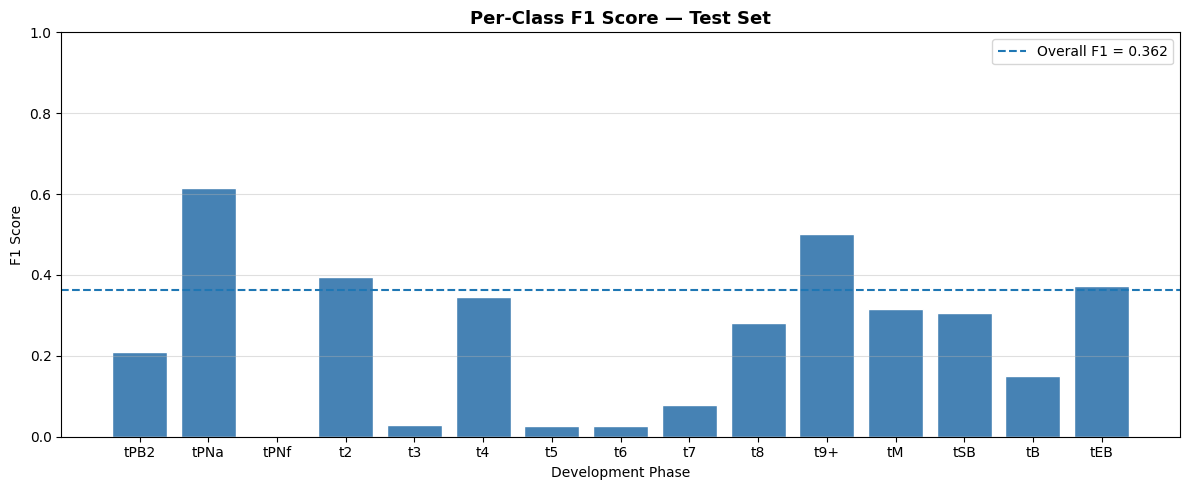

In [23]:
per_class_f1 = f1_score(
    y_true, y_pred,
    average=None,
    labels=present_labels,
    zero_division=0
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(present_names, per_class_f1, color='steelblue', edgecolor='white')


ax.axhline(
    test_f1,
    linestyle='--',
    linewidth=1.5,
    label=f'Overall F1 = {test_f1:.3f}'
)

ax.set_title('Per-Class F1 Score — Test Set', fontsize=13, fontweight='bold')
ax.set_xlabel('Development Phase')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1)

ax.legend()
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('/kaggle/working/per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()